[-1.         -0.97979798 -0.95959596]
[-1. -1.]
[-1.         -0.9029895  -0.81365829]


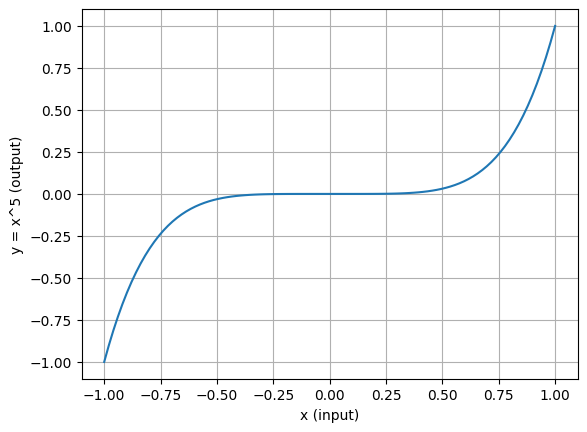

In [1]:
# A simple regression problem using feature engineering.
# Author: Fabrício Galende Marques de Carvalho

from random import shuffle
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

x = np.linspace(-1,1, 100)
x_nn_input = np.column_stack((x, x**3))
y_out = x**5
        

print(x[0:3])
print(x_nn_input[0])
print(y_out[0:3])

# plot input-output pair
plt.plot(x, y_out)
plt.xlabel("x (input)")
plt.ylabel("y = x^5 (output)")
plt.grid()
plt.show()

In [2]:
# Build a new input considering bias:
new_input = []
bias = 1
for x_in in x_nn_input:
    new_input.append(np.concatenate((x_in, np.array([int(bias)]))))
print(new_input[0:3])

[array([-1., -1.,  1.]), array([-0.97979798, -0.94061006,  1.        ]), array([-0.95959596, -0.88361938,  1.        ])]


In [3]:
# now we import, configure and initialized our perceptron
from perceptron import *

# configure the activation function:
def my_activation_function(v):
    return (np.exp(v) - np.exp(-v)) /(np.exp(v)+np.exp(-v))

# freeze random number generator seed to get the same result
np.random.seed(42)  
# build a perceptron instance that uses this activation function.
my_act_function = ActivationFunction(my_activation_function)
my_perceptron = Perceptron(my_act_function, 3, 1)                      
print(my_perceptron.synaptic_weights)

[[0.37454012 0.95071431 0.73199394]]


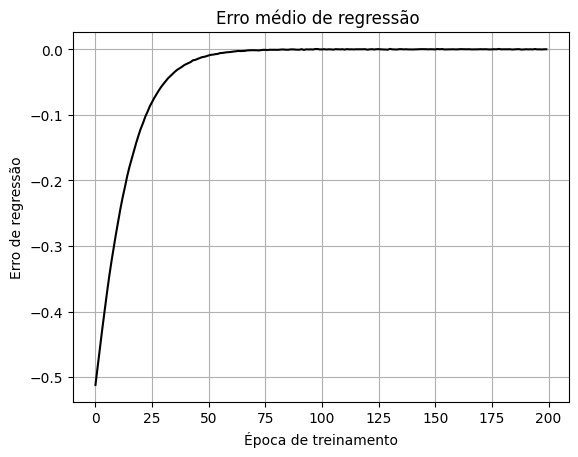

In [4]:
# Now we train our perceptron

learning_rate = 0.001
n_epochs = 200
e_epoch = [] #to store the regression error in each epoch (average)
w_0_epoch = []
indices = list(range(len(y_out)))
e_instantaneous = []
for epoch in range(n_epochs): # for each epoch
    e_point = []
    shuffle(indices)
    for k in indices:    #for each input/output pair
        y_e = my_perceptron.output(new_input[k])
        e_point.append(y_out[k] - y_e[0])
        e_instantaneous.append(y_out[k] - y_e[0])
        my_perceptron.learn([y_out[k]], y_e, new_input[k], learning_rate)
    e_epoch.append( np.mean(e_point) )
    w_0_epoch.append(my_perceptron.synaptic_weights[0][0])

plt.plot(e_epoch, color="black")
plt.title("Erro médio de regressão ")
plt.xlabel("Época de treinamento")
plt.ylabel("Erro de regressão")
plt.grid()

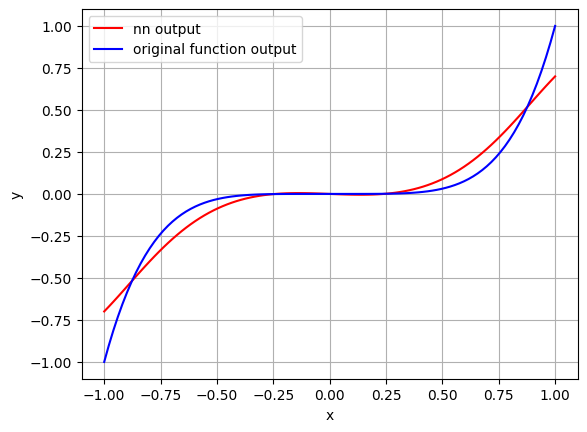

In [5]:
# Now we compare the original nonlinear map to nn output mapping

y_nn = []
for k in range(len(y_out)):
    y_e = my_perceptron.output(new_input[k])
    y_nn.append(y_e)    
plt.plot( x , y_nn, color="red", label="nn output")
plt.plot( x , y_out, color="blue", label = "original function output")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()        
